# Diabetes Data Exploration

In [1]:
# Import libraries
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# Load databset
file_path = "data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path)

In [3]:
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (11744, 9)


,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display Columns of Interest with Descriptions
columns_of_interest = {
    "SEQN": "Respondent sequence number",
    "DIQ010": "Doctor told you have diabetes",
    "DID040": "Age when first told you had diabetes",
    "DIQ160": "Ever told you have prediabetes",
    "DIQ180": "Had blood tested past three years",
    "DIQ050": "Taking insulin now",
    "DID060": "How long taking insulin",
    "DIQ060U": "Unit of measure (month/year)",
    "DIQ070": "Take diabetic pills to lower blood sugar"
}

df = df[list(columns_of_interest.keys())]
df.rename(columns=columns_of_interest, inplace=True)
df.head()

,Respondent sequence number,Doctor told you have diabetes,Age when first told you had diabetes,Ever told you have prediabetes,Had blood tested past three years,Taking insulin now,How long taking insulin,Unit of measure (month/year),Take diabetic pills to lower blood sugar
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Frequency Tables
for col in df.columns[1:]:
    print(f"\n=== Frequency for {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())


=== Frequency for Doctor told you have diabetes ===
Doctor told you have diabetes
1.0     1081
2.0    10371
3.0      284
9.0        4
NaN        4
Name: count, dtype: int64

=== Frequency for Age when first told you had diabetes ===
Age when first told you had diabetes
1.0          1
5.0          1
6.0          2
7.0          3
8.0          4
         ...  
78.0         3
79.0         2
80.0         7
999.0       24
NaN      10663
Name: count, Length: 77, dtype: int64

=== Frequency for Ever told you have prediabetes ===
Ever told you have prediabetes
1.0     918
2.0    7089
9.0      15
NaN    3722
Name: count, dtype: int64

=== Frequency for Had blood tested past three years ===
Had blood tested past three years
1.0    3370
2.0    4667
7.0       2
9.0     265
NaN    3440
Name: count, dtype: int64

=== Frequency for Taking insulin now ===
Taking insulin now
1.0      344
2.0      737
NaN    10663
Name: count, dtype: int64

=== Frequency for How long taking insulin ===
How long taking i

In [6]:
# Missing Values Summary
print("\nMissing Values Summary:")
print(df.isna().sum())


Missing Values Summary:
Respondent sequence number                      0
Doctor told you have diabetes                   4
Age when first told you had diabetes        10663
Ever told you have prediabetes               3722
Had blood tested past three years            3440
Taking insulin now                          10663
How long taking insulin                     11401
Unit of measure (month/year)                11412
Take diabetic pills to lower blood sugar     9463
dtype: int64


In [7]:
def mapping_status(data, mapping):
    labels = []
    for key in mapping:
        count_val = data.get(key, 0)
        labels.append(f"{mapping[key]}\n({count_val})")
    return (list(mapping.keys()), labels)

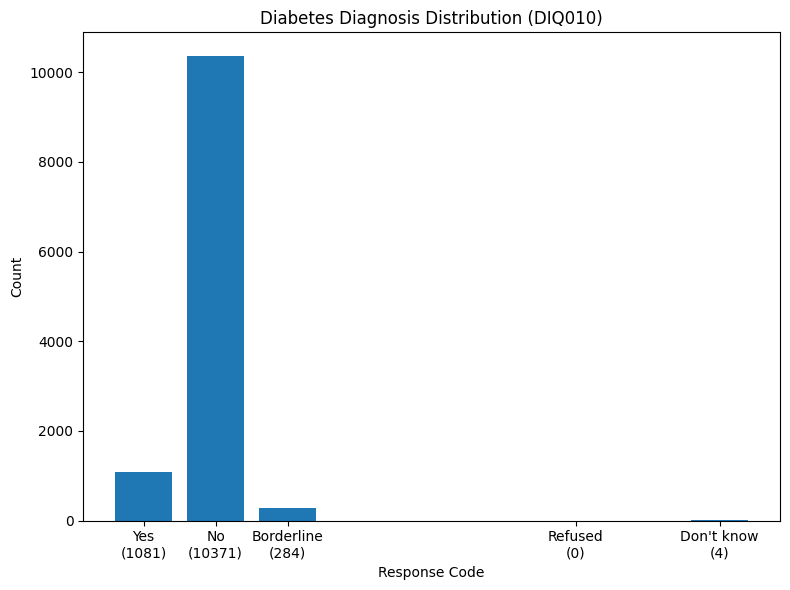

In [8]:
# Visualizing Diabetes Diagnosis Distribution
counts = df['Doctor told you have diabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}

# Create a bar plot using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetes Diagnosis Distribution (DIQ010)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/iabetes_diagnosis_distribution.png")
plt.show()

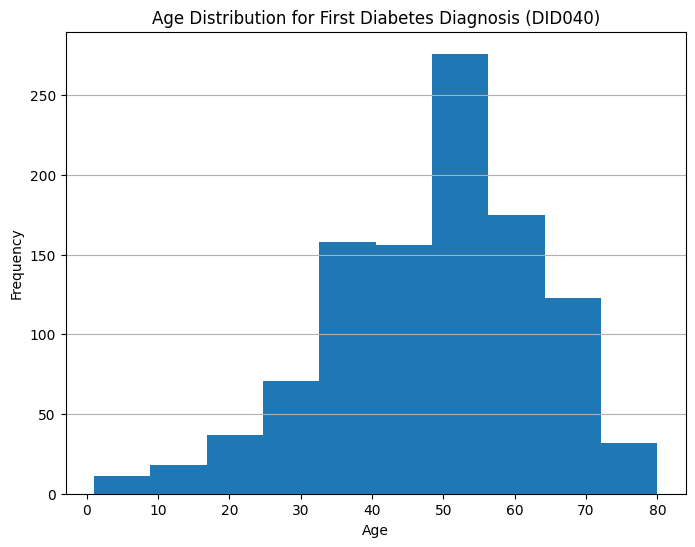

In [9]:
# Graph for Age when first told you had diabetes
age_data = df['Age when first told you had diabetes'].dropna()
age_data_clean = age_data[(age_data >= 1) & (age_data <= 81)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(age_data_clean)
plt.title('Age Distribution for First Diabetes Diagnosis (DID040)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/age_distribution_diabetes_diagnosis.png")
plt.show()

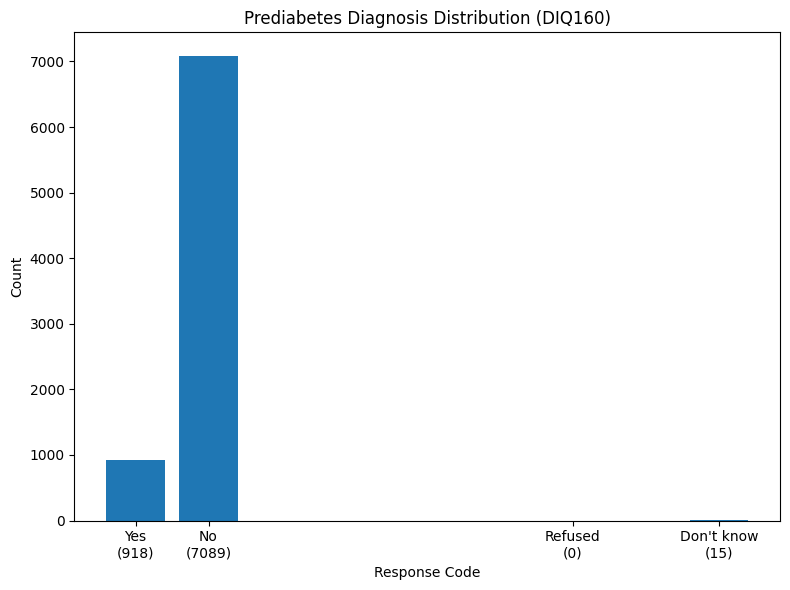

In [10]:
# Graph for Ever told you have prediabetes
counts = df['Ever told you have prediabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Prediabetes Diagnosis Distribution (DIQ160)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/prediabetes_diagnosis_distribution.png")
plt.show()

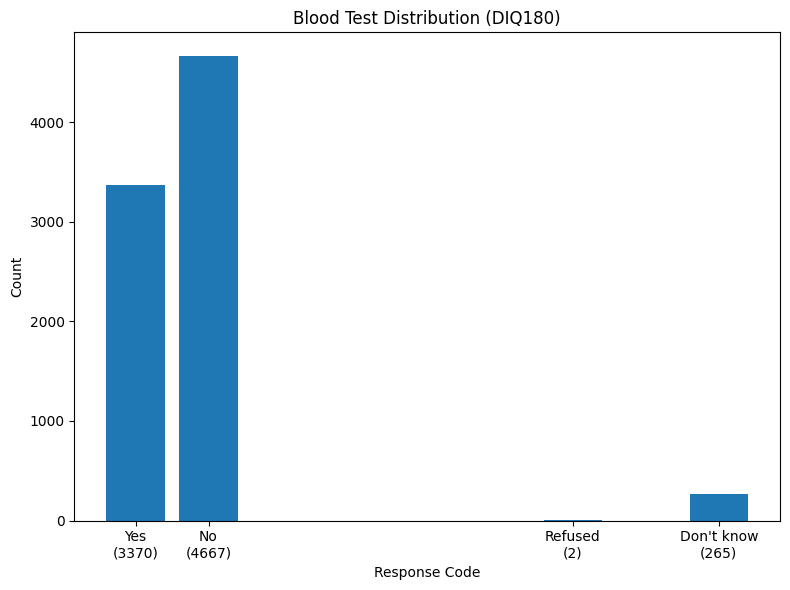

In [11]:
# Graph for Had blood tested past three years
counts = df['Had blood tested past three years'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Blood Test Distribution (DIQ180)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/blood_test_distribution.png")
plt.show()

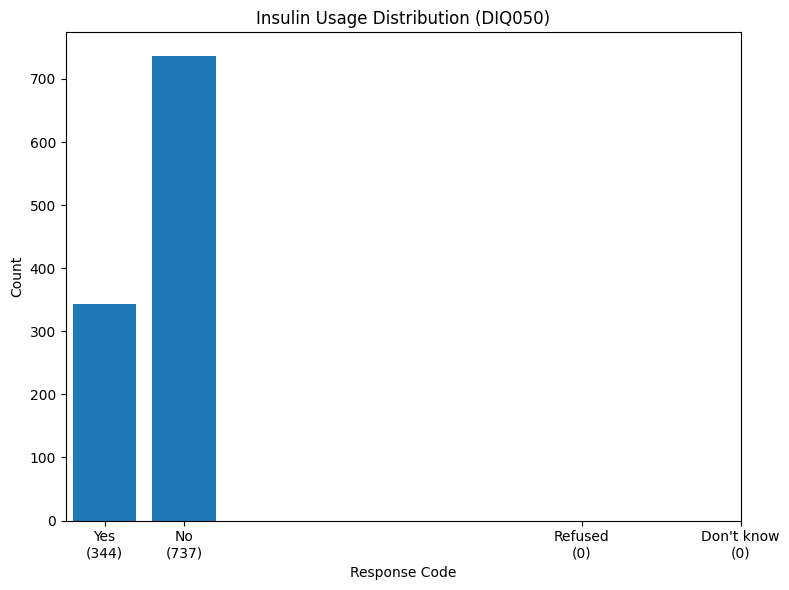

In [12]:
# Graph for Taking insulin now
counts = df['Taking insulin now'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Insulin Usage Distribution (DIQ050)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/insulin_usage_distribution.png")
plt.show()

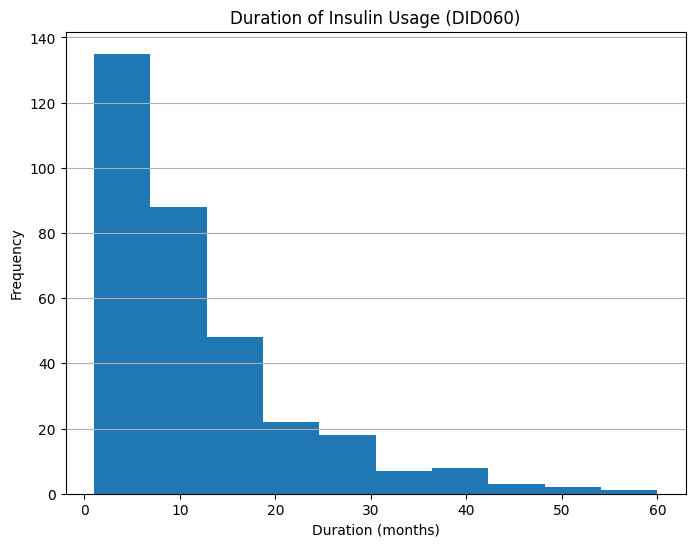

In [13]:
# Graph for How long taking insulin
insulin_duration = df['How long taking insulin'].dropna()
insulin_duration_clean = insulin_duration[(insulin_duration >= 1) & (insulin_duration <= 61)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(insulin_duration_clean)
plt.title('Duration of Insulin Usage (DID060)')
plt.xlabel('Duration (months)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/insulin_duration_distribution.png")
plt.show()

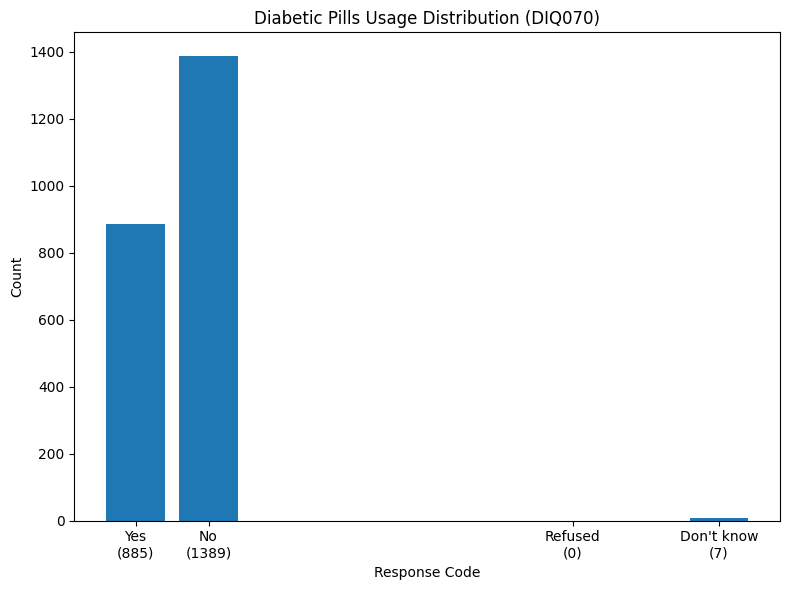

In [14]:
# Graph for Take diabetic pills to lower blood sugar
counts = df['Take diabetic pills to lower blood sugar'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetic Pills Usage Distribution (DIQ070)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/diabetic_pills_distribution.png")
plt.show()

In [15]:
# Save Cleaned Subset
df.to_csv("cleaned/diabetes_cleaned_subset.csv", index=False)

## Making Connections, Yippeeeeee

In [ ]:
# code for combining all of the datasets into one

# import diabetes dataset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path, encoding='cp1252')

# goes through all other files and merges them into the dataframe
dir = 'all_data'
ind = 0
for file in os.scandir(dir):
    if file.is_file():
        print(file)
        ind += 1
        newdf, meta = pyreadstat.read_xport(file, encoding='cp1252')
        df = df.merge(newdf, on="SEQN", how="left", copy=False, suffixes=[f'_x{ind}', f'_y{ind}'])

# create csv from combined dataframe
print(df.head())
df.to_csv('all_data.csv', index=False)

<DirEntry 'ACQ_L.xpt'>
<DirEntry 'AGP_L.xpt'>
<DirEntry 'ALQ_L.xpt'>
<DirEntry 'AUQ_L.xpt'>
<DirEntry 'BAX_L.xpt'>
<DirEntry 'BMX_L.xpt'>
<DirEntry 'BPQ_L.xpt'>
<DirEntry 'BPXO_L.xpt'>
<DirEntry 'CBC_L.xpt'>
<DirEntry 'DBQ_L.xpt'>
<DirEntry 'DEMO_L.xpt'>
<DirEntry 'DEQ_L.xpt'>
<DirEntry 'DPQ_L.xpt'>
<DirEntry 'ECQ_L.xpt'>
<DirEntry 'FASTQX_L.xpt'>
<DirEntry 'FERTIN_L.xpt'>
<DirEntry 'FNQ_L.xpt'>
<DirEntry 'FOLATE_L.xpt'>
<DirEntry 'FOLFMS_L.xpt'>
<DirEntry 'GHB_L.xpt'>
<DirEntry 'GLU_L.xpt'>
<DirEntry 'HDL_L.xpt'>
<DirEntry 'HEPA_L.xpt'>
<DirEntry 'HEPB_S_L.xpt'>
<DirEntry 'HEQ_L.xpt'>
<DirEntry 'HIQ_L.xpt'>
<DirEntry 'HOQ_L.xpt'>
<DirEntry 'HSCRP_L.xpt'>
<DirEntry 'HSQ_L.xpt'>
<DirEntry 'HUQ_L.xpt'>
<DirEntry 'IHGEM_L.xpt'>
<DirEntry 'IMQ_L.xpt'>
<DirEntry 'INQ_L.xpt'>
<DirEntry 'INS_L.xpt'>
<DirEntry 'KIQ_U_L.xpt'>
<DirEntry 'LUX_L.xpt'>
<DirEntry 'MCQ_L.xpt'>
<DirEntry 'OCQ_L.xpt'>
<DirEntry 'OHQ_L.xpt'>
<DirEntry 'PAQY_L.xpt'>
<DirEntry 'PAQ_L.xpt'>
<DirEntry 'PBCD_L.xpt'>
<DirEntr

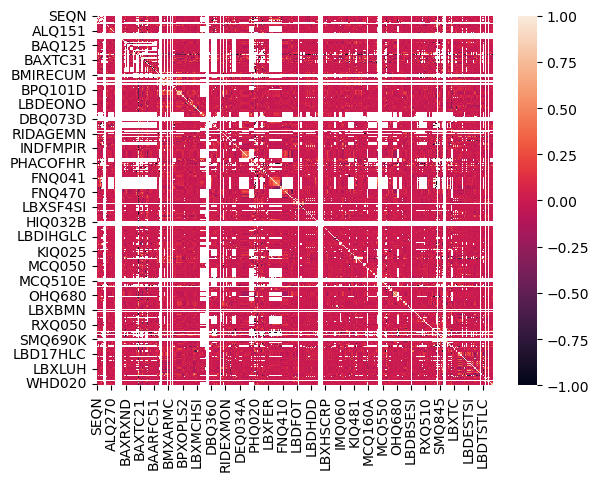

In [12]:
# import csv
df = pd.read_csv('all_data.csv')

# making correlation graph
corrmat = df.corr()
round(corrmat, 2)
sns.heatmap(corrmat)
plt.show()

In [13]:
# gets lists of correlations to DIQ010 (diagnosed w/ diabetes) and the corresponding codes
correlations = corrmat['DIQ010'].dropna().tolist()[2:]
codes = corrmat['DIQ010'].dropna().keys().tolist()[2:]

print(correlations)
print(codes)

[0.003616958110293218, -0.04779448131664238, 0.3985192707973136, 0.00293046472205395, 0.051774158907584286, -0.010745860032985066, -0.048626838779489416, -0.05050237549865332, 0.008998280360351137, -0.031744272811703715, -0.02250004457105218, -0.038669984205594116, -0.06862066072975186, 0.023427912988907597, 0.015831088875758584, -0.06332141650990336, 0.00794442714124861, 0.014424549738728337, 0.06967246201851564, -0.10265217752346072, 0.09292254459331313, 0.023189378864378125, -0.10367686289572393, -0.0795833261495167, 0.042637226814461665, 0.05457107185345192, 0.01730001906355648, 0.0667158379207428, 0.059835001776245914, 0.02814061176975431, 0.01219302779112453, 0.02761563535753046, -0.060104674913941294, -0.00878960323802029, 0.013175106884536134, 0.14434437037837536, 0.24677799168168735, -0.15023026812361304, 0.27216552697590896, -0.04095033463389827, 0.050424783929179096, 0.011426815273673214, -0.26273761113137534, 0.1045090714428379, -0.018486846666163233, -0.045391384753978664,

In [16]:
# create a list of codes with decent correlation, format: (code, correlation)

filtCorrs = []
for i in range(len(correlations)):
    if correlations[i] > 0.1 or correlations[i] < -0.1:
        filtCorrs.append((codes[i], correlations[i]))

print(filtCorrs)
print(f'There are {len(filtCorrs)} codes with a correlation stronger than 0.1')

[('DIQ070', 0.3985192707973136), ('BAXMSTAT', -0.10265217752346072), ('BAX5STAT', -0.10367686289572393), ('BAARFC11', 0.14434437037837536), ('BAXPF12', 0.24677799168168735), ('BAXTC12', -0.15023026812361304), ('BAARFC12', 0.27216552697590896), ('BAXPF22', -0.26273761113137534), ('BAXTC22', 0.1045090714428379), ('BAARFC31', 0.11468019131234186), ('BAXTC32', 0.18648069616261106), ('BAARFC32', 0.37985031781962764), ('BAXTC41', 0.10384558450802128), ('BAXTC42', 0.12864811109941401), ('BMXWT', -0.14320080108353772), ('BMIHT', -0.12243361898618356), ('BMXBMI', -0.15396672633374), ('BMXARMC', -0.13095690436002194), ('BMXWAIST', -0.17664663800210414), ('BPQ020', 0.17204784096888862), ('BPQ080', 0.11620507708752618), ('BPQ101D', 0.1537533186139521), ('BPAOCSZ', -0.10125994772688032), ('BPXOSY1', -0.1074557385005408), ('BPXOSY2', -0.11593674969459869), ('BPXOSY3', -0.10843555973859859), ('LBXRDW', -0.1182704450700429), ('RIDAGEYR', -0.19395862175251666), ('DMDEDUC2', 0.10096733278996572), ('DMDH

Text(0, 0.5, 'Amount of Features')

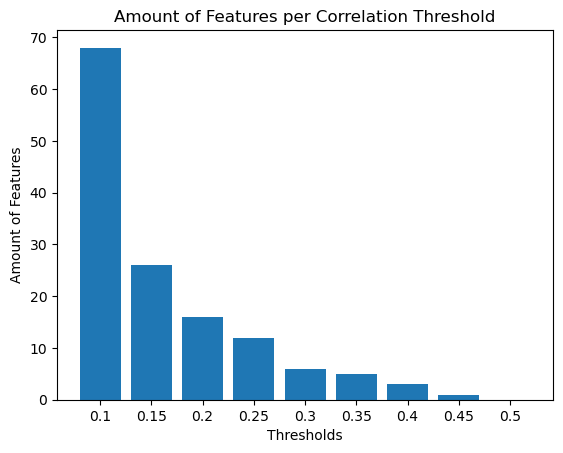

In [14]:
# graph of the amount of features we can get with different correlation thresholds

amounts = []
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    filtCorrs = []
    for i in range(len(correlations)):
        if correlations[i] > t or correlations[i] < t*-1:
            filtCorrs.append((codes[i], correlations[i]))
    amounts.append(len(filtCorrs))


plt.bar(list(map(str, thresholds)), amounts, label = thresholds)
plt.title('Amount of Features per Correlation Threshold')
plt.xlabel('Thresholds')
plt.ylabel('Amount of Features')

In [4]:
codeDict = {
    "DIQ070": ("Diabetes", "Take diabetic pills to lower blood sugar"),
    "BAXMSTAT": ("Balance", "MRT exam status"),
    "BAX5STAT": ("Balance", "Eligibility for Condition 5"),
    "BAARFC11": ("Balance", "MRT cond. 1, trial 1, reason stopped"),
    "BAXPF12": ("Balance", "MRT cond. 1, trial 2, eyes open"),
    "BAXTC12": ("Balance", "MRT cond. 1, trial 2, time"),
    "BAARFC12": ("Balance", "MRT cond. 1, trial 2, reason stopped"),
    "BAXPF22": ("Balance", "MRT cond. 2, trial 2, eyes closed"),
    "BAXTC22": ("Balance", "MRT cond. 2, trial 2, time"),
    "BAARFC31": ("Balance", "MRT cond. 3, trial 1, reason stopped"),
    "BAXTC32": ("Balance", "MRT cond. 3, trial 2, time"),
    "BAARFC32": ("Balance", "MRT cond. 3, trial 2, reason stopped"),
    "BAXTC41": ("Balance", "MRT cond. 4, trial 1, time"),
    "BAXTC42": ("Balance", "MRT cond. 4, trial 2, time"),
    "BMXWT": ("Body Measures", "Weight (kg)"),
    "BMIHT": ("Body Measures", "Standing Height Comment"),
    "BMXBMI": ("Body Measures", "Body Mass Index (kg/m**2)"),
    "BMXARMC": ("Body Measures", "Arm Circumference (cm)"),
    "BMXWAIST": ("Body Measures", "Waist Circumference (cm)"),
    "BPQ020": ("Blood Pressure & Cholesterol", "Ever told you had high blood pressure"),
    "BPQ080": ("Blood Pressure & Cholesterol", "Doctor told you - high cholesterol level"),
    "BPQ101D": ("Blood Pressure & Cholesterol", "Taking meds to lower blood cholesterol?"),
    "BPAOCSZ": ("Blood Pressure - Oscillometric Measurements", "Coded cuff size - oscillometric"),
    "BPXOSY1": ("Blood Pressure - Oscillometric Measurements", "Systolic - 1st oscillometric reading"),
    "BPXOSY2": ("Blood Pressure - Oscillometric Measurements", "Systolic - 2nd oscillometric reading"),
    "BPXOSY3": ("Blood Pressure - Oscillometric Measurements", "Systolic - 3rd oscillometric reading"),
    "LBXRDW": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Red cell distribution width (%)"),
    "RIDAGEYR": ("Demographic Variables and Sample Weights", "Age in years at screening"),
    "DMDEDUC2": ("Demographic Variables and Sample Weights", "Education level - Adults 20+"),
    "DMDHHSIZ": ("Demographic Variables and Sample Weights", "Total number of people in the Household"),
    "PHACOFHR": ("Fasting Questionnaire", "Coffee/tea dast time (hours)"),
    "PHACOFMN": ("Fasting Questionnaire", "Coffee/tea fast time (minutes)"),
    "PHAALCMN": ("Fasting Questionnaire", "Alcohol fast time (minutes)"),
    "LBXFER": ("Ferritin", "Ferritin(ng/mL)"),
    "LBDFERSI": ("Ferritin", "Ferritin(mewg/L)"),
    "FNQ041": ("Functioning", "Difficulty hearing even w/ hearing aids"),
    "FNQ440": ("Functioning", "Difficulty walking or climbing steps"),
    "FNQ490": ("Functioning", "Difficulty using hands and fingers"),
    "FNDADI": ("Functioning", "WG-SS Disability Indicator 18+"),
    "FNDADEDI": ("Functioning", "WG-SS Enhanced Disability Indicator 18+"),
    "LBXSF6SI": ("Serum Folate Forms - Total & Individual - Serum", "Mefox oxidation product (nmol/L)"),
    "LBXGH": ("Glycohemoglobin", "Glycohemoglobin (%)"),
    "LBXGLU": ("Plasma Fasting Glucose", "Fasting Glucose (mg/dL)"),
    "LBDGLUSI": ("Plasma Fasting Glucose", "Fasting Glucose (mmol/L)"),
    "HUQ010": ("Hospital Utilization & Access to Care", "General health condition"),
    "LBXIN": ("Insulin", "Insulin (uU/mL)"),
    "LBDINSI": ("Insulin", "Insulin (pmol/L)"),
    "KIQ005": ("Kidney Conditions - Urology", "How often have urinary leakage"),
    "KIQ052": ("Kidney Conditions - Urology", "How much were daily activities affected"),
    "KIQ481": ("Kidney Conditions - Urology", "How many times wake up and urinate?"),
    "LUARXIN": ("Liver Ultrasound Transient Elastography", "Reason ineligible"),
    "LUXSMED": ("Liver Ultrasound Transient Elastography", "Median stiffness (E), kilopascals (kPa)"),
    "LUXCAOM": ("Liver Ultrasound Transient Elastography", "Median CAP, decibels per meter (dB/m)"),
    "OCD150": ("Occupation", "Type of work done last week"),
    "OHQ845": ("Occupation", "Rate the health of your teeth and gums"),
    "RHQ031": ("Reproductive Health", "Had regular periods in past 12 months"),
    "RHQ078": ("Reproductive Health", "Ever treated for a pelvic infection/PID"),
    "RHD280": ("Reproductive Health", "Had a hysterectomy?"),
    "RXQ510": ("Preventive Aspirin Use", "Dr told to take daily low-dose aspirin?"),
    "RXQ033": ("Prescription Medications", "Taken prescription medicine, past month"),
    "RXQ050": ("Prescription Medications", "Number of prescription medicines taken"),
    "SMQ740": ("Smoking - Recent Tobacco Use", "# days smoked pipe over last 5 days"),
    "SMQ690D": ("Smoking - Recent Tobacco Use", "Used last 5 days - Chewing tobacco"), 
    "LBDAMHLC": ("Sex Steroid Hormone Panel - Serum", "Anti-Mullerian hormone Comment Code"),
    "LBXDHE": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewg/dL)"),
    "LBDDHESI": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewmol/L)")
}